# Object detection — executed examples

This notebook is the live-output companion to the
[Object detection](object-detection.rst) docs page. Every code block
in the .rst page appears here with its actual output baked in so you
can see what the calls return without having to run them yourself.

All examples use the **bundled Landsat 8 test scene and label
polygons** that ship with geowombat — no downloads required. The
scene is surface reflectance (not aerial imagery), and we use the
default `yolov8n.pt` weights pretrained on COCO. This is the wrong
model for satellite imagery so detections will be sparse or absent —
the goal here is to exercise the *plumbing* end-to-end, not to
produce useful labels. See the .rst page for the recommended
DOTA-v1 + OBB setup for real aerial work.

The SAM refinement example from the .rst is **not** executed here
(it needs a ~375 MB checkpoint download). Refer to the .rst for the
code snippet.

## Setup

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
import matplotlib.pyplot as plt

import geowombat as gw
from geowombat.data import (
    l8_224078_20200518,
    l8_224078_20200518_polygons,
)
from geowombat.detect import (
    YOLODetector,
    boxes_from_polygons,
    build_dataset,
    detection_accuracy,
    fit_predict,
    plot_detections,
    predict,
)

# The bundled polygon set has a `name` column with land-cover classes.
# Detection treats it as a generic class column; we rename for clarity.
labels = gpd.read_file(l8_224078_20200518_polygons)
labels['class_name'] = labels['name']
print(sorted(labels['class_name'].unique()))

['crop', 'developed', 'tree', 'water']


## Run a pretrained detector

The simplest workflow: open the raster, hand a `YOLODetector` to
`src.gw.detect`. The result is a `GeoDataFrame` in the raster's CRS.

In [2]:
# Weights file is auto-downloaded on first use.
det = YOLODetector(weights='yolov8n.pt')

with gw.config.update(sensor='bgr', ref_res=300):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        preds = src.gw.detect(
            det,
            tile_size=320,
            overlap=0.0,
            conf=0.05,
            scale=(0, 10000),
        )

print(f'{len(preds)} detections')
print(preds.columns.tolist())
preds.head()

1 detections
['geometry', 'class_id', 'class_name', 'score', 'tile_id']


,geometry,class_id,class_name,score,tile_id
0,"POLYGON ((778472.705 -2831027.666, 778472.705 ...",60,dining table,0.214627,0


The three call shapes below are equivalent — pick whichever reads
best in your code. We only execute the accessor form here; the
other two produce identical output.

In [3]:
with gw.config.update(sensor='bgr', ref_res=300):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        # 1. Accessor (recommended inside `with gw.open(...) as src:`)
        preds_a = src.gw.detect(det, conf=0.05, scale=(0, 10000))

        # 2. Module-level function (parallels gw.ml.predict)
        preds_b = predict(src, det, conf=0.05, scale=(0, 10000))

        # 3. Calling the detector directly
        preds_c = det.predict(src, conf=0.05, scale=(0, 10000))

print(f'accessor: {len(preds_a)}  module: {len(preds_b)}  direct: {len(preds_c)}')

accessor: 1  module: 1  direct: 1


## Sensor config drives band indices

When `gw.config.update(sensor=...)` is active, `src.gw.detect` reads
`src.band.values` and picks the R/G/B triplet automatically — no need
to pass `band_indices` per call.

In [4]:
with gw.config.update(sensor='bgr', ref_res=300):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        print('bands:', src.band.values.tolist())
        preds_auto = src.gw.detect(det, conf=0.05, scale=(0, 10000))

print(f'{len(preds_auto)} detections (band_indices auto-resolved to [2, 1, 0])')

bands: ['blue', 'green', 'red']
1 detections (band_indices auto-resolved to [2, 1, 0])


## Convert polygon labels to boxes

`boxes_from_polygons` replaces polygon geometries with either
axis-aligned envelopes (**AABB**) or minimum rotated rectangles
(**OBB**). For overhead / aerial imagery, OBB is almost always the
right choice — see the .rst page for the full guidance and the
DOTA-v1 weights recommendation.

In [5]:
aabb = boxes_from_polygons(labels, oriented=False)
obb  = boxes_from_polygons(labels, oriented=True)
print('aabb kinds:', aabb['_box_kind'].unique().tolist())
print('obb  kinds:', obb['_box_kind'].unique().tolist())
print()
print('first AABB geometry:', aabb.geometry.iloc[0].wkt[:80], '...')
print('first OBB  geometry:', obb.geometry.iloc[0].wkt[:80], '...')

aabb kinds: ['aabb']
obb  kinds: ['obb']

first AABB geometry: POLYGON ((737544.502430237 -2795632.5053249793, 738061.8046601362 -2795632.50532 ...
first OBB  geometry: POLYGON ((737544.502430237 -2795632.5053249793, 737544.502430237 -2795232.771783 ...


## Build a YOLO training dataset

`src.gw.to_yolo_dataset` tiles the raster + label GeoDataFrame into
an Ultralytics-layout directory on disk.

In [6]:
from pathlib import Path
import tempfile

with tempfile.TemporaryDirectory() as td:
    out_dir = Path(td) / 'yolo_lc'
    with gw.config.update(sensor='bgr', ref_res=300):
        with gw.open(l8_224078_20200518, nodata=0) as src:
            info = src.gw.to_yolo_dataset(
                labels,
                class_col='class_name',
                out_dir=out_dir,
                tile_size=128,
                overlap=0.0,
                val_split=0.25,
                min_box_pixels=2,
                scale=(0, 10000),
                background_ratio=0.0,
            )
    # Strip the tempdir prefix for a stable printed output.
    info_display = {k: (str(v).split(td)[-1] if isinstance(v, str) and td in str(v) else v)
                    for k, v in info.items()}
print(info_display)

{'out_dir': '/yolo_lc', 'classes': ['crop', 'developed', 'tree', 'water'], 'n_train': 2, 'n_val': 2, 'n_boxes': 4, 'empty_kept': 0, 'empty_skipped': 0}


Equivalent module-level form via `build_dataset`:

In [7]:
with tempfile.TemporaryDirectory() as td:
    out_dir = Path(td) / 'yolo_lc'
    with gw.config.update(sensor='bgr', ref_res=300):
        with gw.open(l8_224078_20200518, nodata=0) as src:
            info = build_dataset(
                src, labels, class_col='class_name',
                out_dir=out_dir, tile_size=128,
                scale=(0, 10000), min_box_pixels=2,
            )
print('classes:', info['classes'])
print('n_train:', info['n_train'], ' n_val:', info['n_val'],
      ' n_boxes:', info['n_boxes'])

classes: ['crop', 'developed', 'tree', 'water']
n_train: 3  n_val: 1  n_boxes: 4


## End-to-end: build, fine-tune, predict

`fit_predict` builds a dataset, fine-tunes the model for one epoch,
and runs inference — all in a single call. With only 4 bundled
polygons the trained model can't learn much, but the call exercises
the full pipeline.

In [8]:
with tempfile.TemporaryDirectory() as td:
    det_ft = YOLODetector(weights='yolov8n.pt')
    with gw.config.update(sensor='bgr', ref_res=300):
        with gw.open(l8_224078_20200518, nodata=0) as src:
            preds_ft, summary = fit_predict(
                src,
                det_ft,
                labels,
                class_col='class_name',
                out_dir=Path(td) / 'ds',
                tile_size=128,
                overlap=0.0,
                epochs=1,
                min_box_pixels=2,
                scale=(0, 10000),
                val_split=0.5,
                seed=42,
                predict_kwargs={'conf': 0.05},
            )
print('classes trained on:', summary['classes'])
print(f'{summary["n_boxes"]} training boxes')
print(f'{len(preds_ft)} predictions from the fine-tuned model')

New https://pypi.org/project/ultralytics/8.4.52 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.51 🚀 Python-3.11.14 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11911MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/tmpzx3gqc3n/ds/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None

Overriding model.yaml nc=80 with nc=4



                   from  n    params  module                                       arguments                     


...

                   all          3          3          0          0          0          0


                  crop          3          3          0          0          0          0


Speed: 0.0ms preprocess, 0.9ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to /home/mmann1123/Documents/github/geowombat/doc/source/runs/detect/train-2


classes trained on: ['crop', 'developed', 'tree', 'water']
4 training boxes
0 predictions from the fine-tuned model


## Accuracy assessment

`detection_accuracy` computes per-class precision/recall/F1/AP at
one or more IoU thresholds. The bundled polygons aren't really a
fair test for COCO-pretrained YOLO, so we re-tag predictions as
`'developed'` to force a spatial comparison and see the metric
machinery work end-to-end.

In [9]:
det_eval = YOLODetector(weights='yolov8n.pt')
with gw.config.update(sensor='bgr', ref_res=300):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        preds_eval = src.gw.detect(
            det_eval, tile_size=320, overlap=0.0,
            conf=0.05, scale=(0, 10000),
        )

preds_eval = preds_eval.copy()
preds_eval['class_name'] = 'developed'

results = detection_accuracy(
    predictions=preds_eval,
    truth=labels[['class_name', 'geometry']],
    class_col='class_name',
    iou_thresholds=(0.3, 0.5),
)
print('Per-class metrics:')
print(results['metrics'])
print()
print('Summary:', results['summary'])

Per-class metrics:
                          ap  precision  recall   f1  tp  fp  fn  support
iou_threshold class                                                      
0.3           crop       0.0        0.0     0.0  0.0   0   0   1        1
              developed  0.0        0.0     0.0  0.0   0   1   1        1
              tree       0.0        0.0     0.0  0.0   0   0   1        1
              water      0.0        0.0     0.0  0.0   0   0   1        1
0.5           crop       0.0        0.0     0.0  0.0   0   0   1        1
              developed  0.0        0.0     0.0  0.0   0   1   1        1
              tree       0.0        0.0     0.0  0.0   0   0   1        1
              water      0.0        0.0     0.0  0.0   0   0   1        1

Summary: {'mAP@0.3': 0.0, 'mAP@0.5': 0.0}


## Visualize TP / FP / FN

`plot_detections` overlays the raster with predictions and truth,
color-coded by status. Pass the `matched` GeoDataFrame from
`detection_accuracy` to keep colors consistent with the metrics.

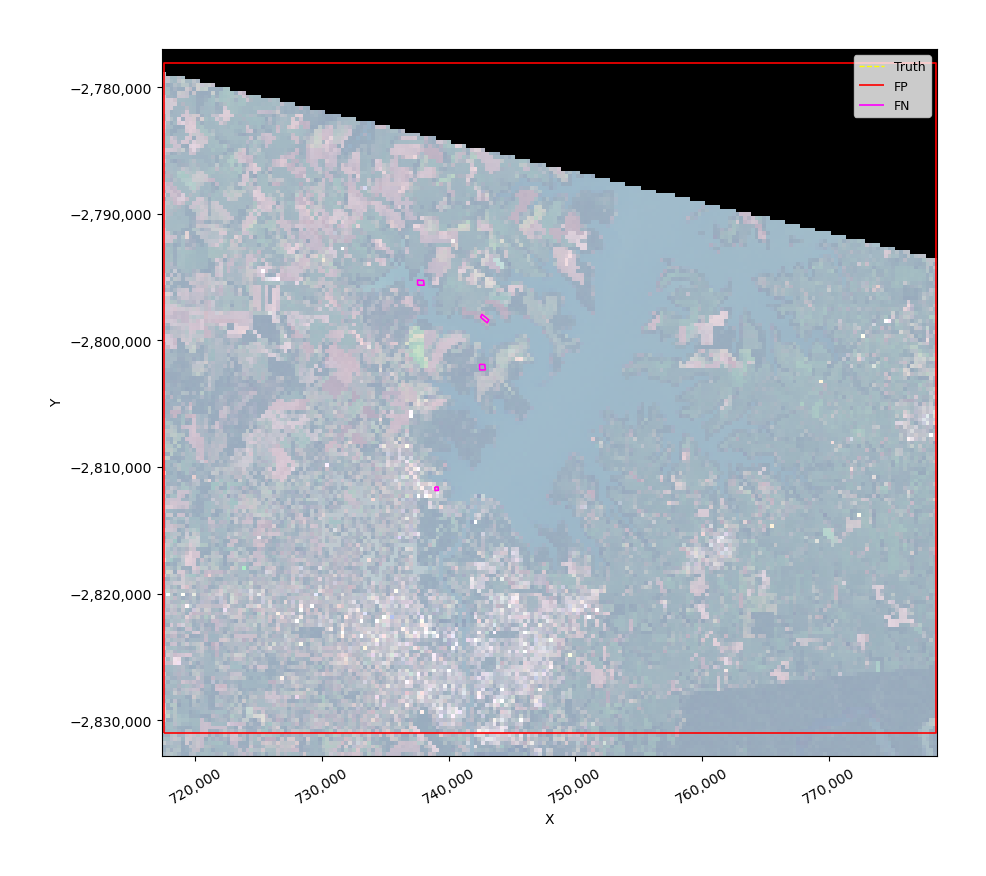

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
with gw.config.update(sensor='bgr', ref_res=300):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        plot_detections(
            src,
            predictions=results['matched'],
            truth=labels,
            ax=ax,
            scale=(0, 10000),
        )
plt.show()

## QGIS review round-trip

`export_for_review` writes a GeoPackage you can step through
feature-by-feature in QGIS. After a human fills in the
`reviewer_label` field, `recompute_from_review` re-derives metrics
from the corrected file.

In [11]:
from geowombat.detect import export_for_review

with tempfile.TemporaryDirectory() as td:
    review_path = Path(td) / 'review.gpkg'
    export_for_review(results['matched'], review_path)
    print(f'Wrote {review_path.name} '
          f'({review_path.stat().st_size // 1024} KB) — '
          f'open in QGIS to step through detections.')

Wrote review.gpkg (96 KB) — open in QGIS to step through detections.


## Next steps

- For real aerial / satellite work, swap `yolov8n.pt` for
  `yolov8n-obb.pt` (DOTA-v1 pretrained) and pass `oriented=True`
  when building the dataset. See the .rst page for the full
  guidance and the *Digitizing polygons for high-quality OBB
  labels* subsection.
- For polygon footprints (instead of boxes), refine detections
  with `SAMRefiner` — see the .rst page for the code snippet and
  the heavier `notebooks/object_detection.ipynb` for the executed
  NAIP + buildings example.